In [6]:
#Data Stories_02/ Heat Wave trend in India

In [7]:
import pandas as pd
import numpy as np

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [9]:
days=pd.read_csv("days.csv")
deaths=pd.read_csv("deaths.csv")

In [10]:
print(deaths.head())

   Year  Deaths due to Heat wave
0  2010                      269
1  2011                       12
2  2012                      729
3  2013                     1433
4  2014                      548


In [11]:
print(days.head())

   Sl. No.      State / UT  2011  2012  2013  2014  2015  2016  2017  2018  \
0        1  Andhra Pradesh   8.0  16.0  11.0  16.0   7.0  10.0  10.0   8.0   
1        2           Assam   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2        3           Bihar   1.0  20.0   1.0   9.0   5.0  11.0   3.0   6.0   
3        4    Chhattisgarh   1.0   6.0   3.0   6.0   1.0   2.0   3.0   0.0   
4        5           Delhi   1.0  11.0   7.0   7.0   3.0   2.0   9.0   6.0   

   2019  2020  2021  
0  13.0   3.0   4.0  
1   0.0   0.0   0.0  
2  12.0   1.0   1.0  
3   3.0   0.0   1.0  
4   8.0   4.0   3.0  


In [12]:
print(deaths.describe())

              Year  Deaths due to Heat wave
count     9.000000                 9.000000
mean   2014.000000               685.222222
std       2.738613               679.481379
min    2010.000000                12.000000
25%    2012.000000               269.000000
50%    2014.000000               548.000000
75%    2016.000000               729.000000
max    2018.000000              2081.000000


In [13]:
print(days.describe())

         Sl. No.      2011       2012       2013       2014       2015  \
count  22.000000  20.00000  20.000000  20.000000  20.000000  20.000000   
mean   11.500000   2.00000  10.050000   5.000000   7.200000   4.300000   
std     6.493587   2.36198   7.762765   3.583588   4.958777   3.229795   
min     1.000000   0.00000   0.000000   0.000000   0.000000   0.000000   
25%     6.250000   0.75000   3.750000   1.750000   3.000000   2.000000   
50%    11.500000   1.00000   8.500000   5.000000   7.000000   3.500000   
75%    16.750000   2.25000  17.000000   8.000000  10.250000   7.000000   
max    22.000000   8.00000  27.000000  11.000000  17.000000  11.000000   

            2016       2017       2018       2019       2020       2021  
count  20.000000  20.000000  20.000000  20.000000  20.000000  20.000000  
mean    7.500000   6.150000   4.500000   8.700000   2.100000   1.800000  
std     5.567764   4.344082   4.186444   5.361657   1.803505   1.935812  
min     0.000000   0.000000   0.00000

In [14]:
print(days.isnull().sum())

Sl. No.       0
State / UT    0
2011          2
2012          2
2013          2
2014          2
2015          2
2016          2
2017          2
2018          2
2019          2
2020          2
2021          2
dtype: int64


In [15]:
print(deaths.isnull().sum())

Year                       0
Deaths due to Heat wave    0
dtype: int64


In [16]:
print(days.columns)

Index(['Sl. No.', 'State / UT', '2011', '2012', '2013', '2014', '2015', '2016',
       '2017', '2018', '2019', '2020', '2021'],
      dtype='object')


In [17]:
print(deaths.columns)

Index(['Year', 'Deaths due to Heat wave'], dtype='object')


In [18]:
fig1 = px.bar(
    deaths,
    x="Year",
    y="Deaths due to Heat wave",
    title="Heatwave Deaths in India (2010–2018)",)
fig1.show()

2015 had the highest number of deaths (2081) and 2011 had the least deaths (12) recorded. This signifies there is uneven trend in the deaths due to heat waves in India.

In [19]:
year_columns = [str(year) for year in range(2011, 2022)]
days["Total Heatwave Days"] = days[year_columns].sum(axis=1)

In [20]:
days[["State / UT", "Total Heatwave Days"]].head()

,State / UT,Total Heatwave Days
0,Andhra Pradesh,106.0
1,Assam,0.0
2,Bihar,70.0
3,Chhattisgarh,26.0
4,Delhi,61.0


In [21]:
days = days.sort_values(
    by="Total Heatwave Days",
    ascending=False)

In [22]:
fig2 = px.bar(
    days,
    x="Total Heatwave Days",
    y="State / UT",
    orientation="h",
    title="Total Heatwave Days Reported by State (2011–2021)")
fig2.show()

Rajasthan recorded a total of 119 days with severe heat wave days. While Karnataka recorded the lowest (amongst the data available). Rajasthan reports approximately 8 times the recorded severe heat waves days recorded in Karnataka.

In [23]:
national_trend = days[year_columns].sum()
national_trend

,0
2011,40.0
2012,201.0
2013,100.0
2014,144.0
2015,86.0
2016,150.0
2017,123.0
2018,90.0
2019,174.0
2020,42.0


In [24]:
national_trend = national_trend.reset_index()
national_trend.columns = ["Year", "Heatwave Days"]

In [25]:
fig = px.line(
    national_trend,
    x="Year",
    y="Heatwave Days",
    markers=True,
    title="Total Heatwave Days Reported Across India (2011–2021)")
fig.show()

It is observed that there is an uneven trend in the heatwave days across years. Some years recorded the highest number of days (2012, 2019, for instance) while some years have shown the least recorded heat wave days like in 2011, 2020 and 2021.  

In [26]:
national_trend["Year"] = national_trend["Year"].astype(int)
comparison = pd.merge(
    national_trend,
    deaths,
    on="Year")
comparison

,Year,Heatwave Days,Deaths due to Heat wave
0,2011,40.0,12
1,2012,201.0,729
2,2013,100.0,1433
3,2014,144.0,548
4,2015,86.0,2081
5,2016,150.0,700
6,2017,123.0,375
7,2018,90.0,20


In [27]:
import plotly.express as px
fig3 = px.scatter(
    comparison,
    x="Heatwave Days",
    y="Deaths due to Heat wave",
    hover_name="Year",
    trendline="ols",
    title="Relationship Between Heatwave Days and Heatwave Deaths")
fig3.show()

This trendline shows that there is a significant relationship between heatwave days and the consequent deaths associated with it. More persistent are the heat wave days, more are the deaths recorded. There are 2 outliers - in 2015 and 2013, the number of deaths due to heat wave days were recorded the maximum.

In [28]:
correlation = comparison["Heatwave Days"].corr(comparison["Deaths due to Heat wave"])
print(correlation)

0.05161665624240652


There exist a moderate positive relationship between the number of heat wave days and the increasing deaths due to heatwave.

In [29]:
top10 = days.sort_values(
    by="Total Heatwave Days",
    ascending=False
).head(10)
top10

,Sl. No.,State / UT,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,Total Heatwave Days
16,17,Rajasthan,7.0,7.0,9.0,11.0,9.0,15.0,14.0,17.0,20.0,6.0,4.0,119.0
0,1,Andhra Pradesh,8.0,16.0,11.0,16.0,7.0,10.0,10.0,8.0,13.0,3.0,4.0,106.0
14,15,Odisha,2.0,18.0,9.0,17.0,11.0,19.0,9.0,4.0,8.0,2.0,4.0,103.0
8,9,Jharkhand,1.0,19.0,5.0,7.0,9.0,16.0,10.0,3.0,10.0,1.0,0.0,81.0
15,16,Punjab,6.0,17.0,11.0,12.0,3.0,5.0,12.0,4.0,8.0,1.0,2.0,81.0
6,7,Haryana,3.0,8.0,8.0,9.0,4.0,10.0,13.0,9.0,8.0,3.0,2.0,77.0
19,20,Uttar Pradesh,2.0,17.0,6.0,9.0,8.0,5.0,4.0,6.0,13.0,2.0,1.0,73.0
20,21,Uttarakhand,0.0,27.0,2.0,3.0,2.0,9.0,4.0,5.0,13.0,0.0,7.0,72.0
2,3,Bihar,1.0,20.0,1.0,9.0,5.0,11.0,3.0,6.0,12.0,1.0,1.0,70.0
11,12,Madhya Pradesh,2.0,4.0,5.0,10.0,4.0,10.0,7.0,7.0,13.0,2.0,1.0,65.0


Rajasthan, Andhra Pradesh, Odisha, Jharkhand, Punjab, Haryana, Uttar Pradesh, Uttarakhand, Bihar and Madhya Pradesh have the maximum number of total heatwave days recorded from 2011-2021.

In [30]:
days["Risk Level"] = pd.qcut(
    days["Total Heatwave Days"],
    q=4,
    labels=["Low","Moderate","High","Very High"])

This column shows the intensity of risk due to heat wave for each state. It is classified into 4 risk quartiles ie. Low, Moderate, High and Very High. General Observation: The North Eastern states and the Southern States fall under Low rik and Moderate risk zones. Andhra Pradesh is an exception which has recorded Very High Risk zone.

In [31]:
days[["State / UT","Total Heatwave Days","Risk Level"]]

,State / UT,Total Heatwave Days,Risk Level
16,Rajasthan,119.0,Very High
0,Andhra Pradesh,106.0,Very High
14,Odisha,103.0,Very High
8,Jharkhand,81.0,Very High
15,Punjab,81.0,Very High
6,Haryana,77.0,Very High
19,Uttar Pradesh,73.0,High
20,Uttarakhand,72.0,High
2,Bihar,70.0,High
11,Madhya Pradesh,65.0,High


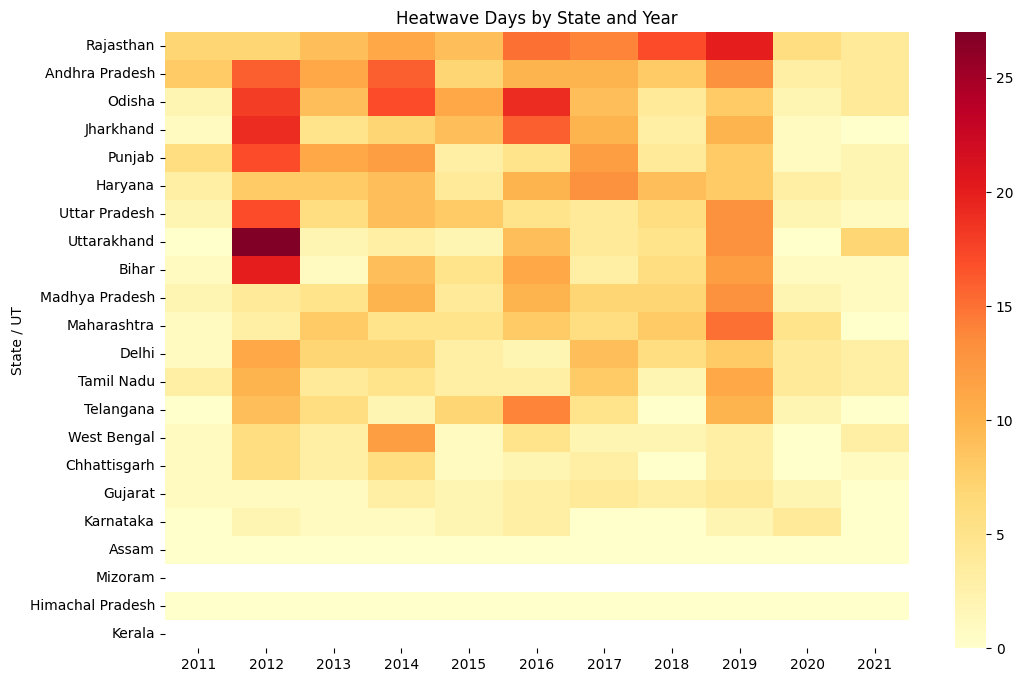

In [32]:
import seaborn as sns
year_columns = [str(i) for i in range(2011, 2022)]
heatmap_data = days.set_index("State / UT")[year_columns]
plt.figure(figsize=(12,8))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd")
plt.title("Heatwave Days by State and Year")
plt.show()

In [33]:
fig = px.scatter(
    days,
    x="Total Heatwave Days",
    y="State / UT",
    size="Total Heatwave Days",
    color="Risk Level",
    hover_name="State / UT",
    size_max=50,
    title="Heatwave Exposure by State")
fig.show()

Rajasthan, Andhra Pradesh, Odisha, Punjab, Jharkhand and Haryana are classified as Very Hisk risk zones. Uttar Pradesh, Bihar, Uttarakhand, Madhya Pradesha and Maharashtra are under High Risk zone.

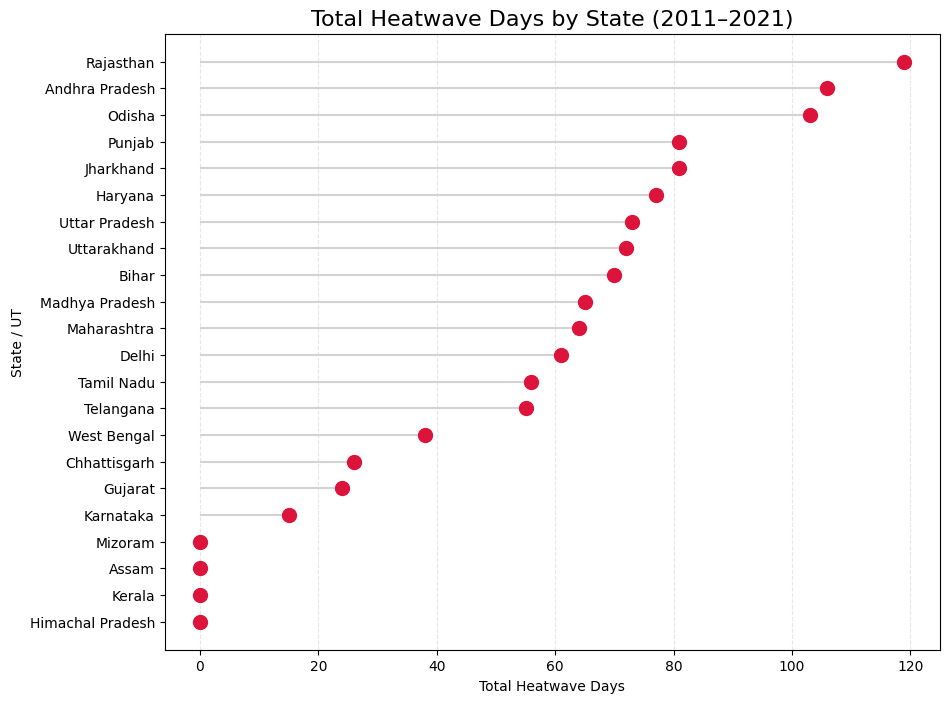

In [34]:
days_sorted = days.sort_values("Total Heatwave Days")
plt.figure(figsize=(10,8))
plt.hlines(
    y=days_sorted["State / UT"],
    xmin=0,
    xmax=days_sorted["Total Heatwave Days"],
    color="lightgray")
plt.plot(
    days_sorted["Total Heatwave Days"],
    days_sorted["State / UT"],
    "o",
    markersize=10,
    color="crimson")
plt.title("Total Heatwave Days by State (2011–2021)", fontsize=16)
plt.xlabel("Total Heatwave Days")
plt.ylabel("State / UT")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()


In [35]:
fig = px.bar_polar(
    days,
    r="Total Heatwave Days",
    theta="State / UT",
    color="Risk Level",
   template="plotly_white",
    title="Heatwave Exposure Across Indian States")
fig.show()

Dehi, Tamil Nadu, Chhattisgarh, Telangana and West Bengal fall under Moderate risk zones.

## Policy Recommendations

Based on the findings, the policymakers should prioritise strengthening state-specific Heat Action Plans in high-exposure regions. There is a need to expand early warning systems, improve public awareness campaigns and integrate heatwave preparedness into urban planning and public health strategies. Long-term climate adaptation policies should focus on protecting vulnerable populations through data-driven resource allocation and continuous monitoring of heatwave trends.